# SVM (one-vs-all, lineaire)

Plan :
1. Cas logiques : OR, AND (lineairement separables), XOR, XNOR (non separables)
2. Frontiere de decision : OR vs XOR
3. Cas non lineaire (cercle) -- limite du SVM lineaire

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "python")))

import numpy as np
import matplotlib.pyplot as plt
from svm import lib, entrainer_svm, predire_svm, precision_svm


def dessiner_frontiere(model, X, labels, titre):
    """Affiche la frontiere de decision du modele sur des points 2D"""
    X = np.array(X, dtype=float)
    pas = 0.05
    valeurs_x = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, pas)
    valeurs_y = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, pas)

    Z = [[predire_svm(model, [x, y]) for x in valeurs_x] for y in valeurs_y]

    plt.contourf(valeurs_x, valeurs_y, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", edgecolors="k", s=80)
    plt.title(titre)
    plt.show()

## 1. Cas logiques

In [2]:
def test_porte(nom, inputs, labels):
    model = entrainer_svm(inputs, labels, nb_classes=2)

    print(f"\n=== Porte {nom} ===")
    succes = True
    for x, y in zip(inputs, labels):
        pred = predire_svm(model, x)
        ok = (pred == y)
        succes = succes and ok
        print(f"  entree {x} | attendu {y} | predit {pred}  {'OK' if ok else 'ERREUR'}")
    print(f"  -> {nom} : {'SUCCES' if succes else 'ECHEC'}")

    lib.destroy_svm_model(model)
    return succes


inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
test_porte("OR",   inputs, [0, 1, 1, 1])
test_porte("AND",  inputs, [0, 0, 0, 1])
test_porte("XOR",  inputs, [0, 1, 1, 0])
test_porte("XNOR", inputs, [1, 0, 0, 1])


=== Porte OR ===
  entree [0.0, 0.0] | attendu 0 | predit 0  OK
  entree [0.0, 1.0] | attendu 1 | predit 1  OK
  entree [1.0, 0.0] | attendu 1 | predit 1  OK
  entree [1.0, 1.0] | attendu 1 | predit 1  OK
  -> OR : SUCCES

=== Porte AND ===
  entree [0.0, 0.0] | attendu 0 | predit 0  OK
  entree [0.0, 1.0] | attendu 0 | predit 0  OK
  entree [1.0, 0.0] | attendu 0 | predit 0  OK
  entree [1.0, 1.0] | attendu 1 | predit 1  OK
  -> AND : SUCCES

=== Porte XOR ===
  entree [0.0, 0.0] | attendu 0 | predit 0  OK
  entree [0.0, 1.0] | attendu 1 | predit 0  ERREUR
  entree [1.0, 0.0] | attendu 1 | predit 0  ERREUR
  entree [1.0, 1.0] | attendu 0 | predit 0  OK
  -> XOR : ECHEC

=== Porte XNOR ===
  entree [0.0, 0.0] | attendu 1 | predit 1  OK
  entree [0.0, 1.0] | attendu 0 | predit 1  ERREUR
  entree [1.0, 0.0] | attendu 0 | predit 1  ERREUR
  entree [1.0, 1.0] | attendu 1 | predit 1  OK
  -> XNOR : ECHEC


False

## 2. Frontiere de decision : OR vs XOR

Le SVM ici est **lineaire** (produit scalaire simple, pas de noyau) : il ne peut
tracer qu'une droite. OR est lineairement separable, XOR ne l'est pas -- echec
garanti quel que soit l'entrainement (meme limite que le modele lineaire simple).

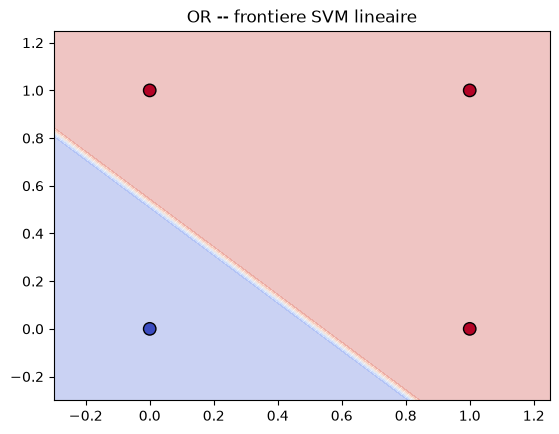

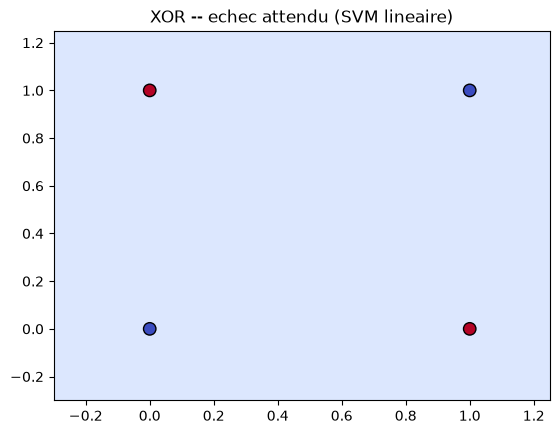

In [3]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]

labels_or = [0, 1, 1, 1]
model_or = entrainer_svm(inputs, labels_or, nb_classes=2)
dessiner_frontiere(model_or, inputs, labels_or, "OR -- frontiere SVM lineaire")
lib.destroy_svm_model(model_or)

labels_xor = [0, 1, 1, 0]
model_xor = entrainer_svm(inputs, labels_xor, nb_classes=2)
dessiner_frontiere(model_xor, inputs, labels_xor, "XOR -- echec attendu (SVM lineaire)")
lib.destroy_svm_model(model_xor)

## 3. Sauvegarde et chargement du modele

In [5]:
os.makedirs(os.path.join("..", "models"), exist_ok=True)
chemin = os.path.join("..", "models", "svm_or.txt")

model_or = entrainer_svm(inputs, labels_or, nb_classes=2)
lib.save_svm(model_or, chemin.encode())
lib.destroy_svm_model(model_or)

model_charge = lib.load_svm(chemin.encode())
for x, y in zip(inputs, labels_or):
    print(f"  entree {x} | attendu {y} | predit (modele recharge) {predire_svm(model_charge, x)}")
lib.destroy_svm_model(model_charge)

  entree [0.0, 0.0] | attendu 0 | predit (modele recharge) 0
  entree [0.0, 1.0] | attendu 1 | predit (modele recharge) 1
  entree [1.0, 0.0] | attendu 1 | predit (modele recharge) 1
  entree [1.0, 1.0] | attendu 1 | predit (modele recharge) 1
